In [23]:
from doctest import debug
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt

# Point sys.path to the repository root
repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:

# Import the PhaseMapGenerator (assuming you saved it in src/phase_map_generator.py)
# from src.phase_map_generator import PhaseMapGenerator
import config
import src.phase_extraction as pe
import src.calibration as calib

# Phase extraction at 90 degrees

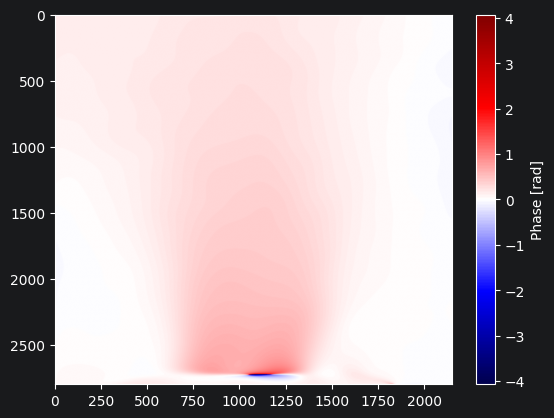

In [31]:
hdf5_path = r"C:\Users\vmlab\Documents\data\files\2026\09\23\nozzle_153\Ar_5_bar\90_deg"

roi = [2000, 5000, 1300, 3650]  # [x_start, x_end, y_start, y_end]
ref_img, exp_img, ref_roi, exp_roi = pe.get_interferometry_images(hdf5_path, roi=roi)

ref_fourier_shifted = pe.get_fourier(ref_roi)
exp_fourier_shifted = pe.get_fourier(exp_roi)

dominant_frequency = pe.get_dominant_frequency(ref_fourier_shifted, debug = False)

delta_phase_wrapped = pe.get_delta_phase_wrapped(ref_fourier_shifted, exp_fourier_shifted, dominant_frequency, debug = False)
ref_edge, *_ = calib.estimate_nozzle_edge(ref_roi)
x_left, x_right = calib.detect_nozzle_x_range(ref_roi, ref_edge)
calibrated_phase, _ = calib.calibrate_phase(delta_phase_wrapped, ref_edge, x_left, x_right, debug = True)


# Phase extraction for nozzle_153 at 0 degrees

Unsupported data type for _convert.
Unsupported data type for _convert.


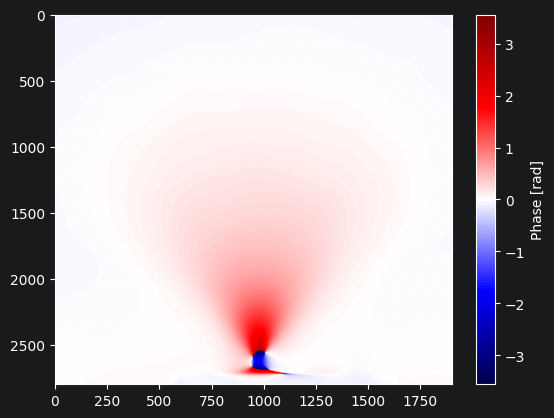

In [33]:
hdf5_path = r"C:\Users\vmlab\Documents\data\files\2026\09\23\nozzle_153\Ar_5_bar\0_deg"

roi = [2000, 5000, 1300, 3400]  # [x_start, x_end, y_start, y_end]
ref_img, exp_img, ref_roi, exp_roi = pe.get_interferometry_images(hdf5_path, roi=roi)

ref_fourier_shifted = pe.get_fourier(ref_roi)
exp_fourier_shifted = pe.get_fourier(exp_roi)

dominant_frequency = pe.get_dominant_frequency(ref_fourier_shifted, debug = False)

delta_phase_wrapped = pe.get_delta_phase_wrapped(ref_fourier_shifted, exp_fourier_shifted, dominant_frequency, debug = False)
ref_edge, *_ = calib.estimate_nozzle_edge(ref_roi)
x_left, x_right = calib.detect_nozzle_x_range(ref_roi, ref_edge)
calibrated_phase, _ = calib.calibrate_phase(delta_phase_wrapped, ref_edge, x_left, x_right, debug = True)
